For this task, ill be attempting to implement basic arithmetic circuits through qiskit.
A sum of a and b can be simplified into a XOR b
its carry can be placed into a AND B

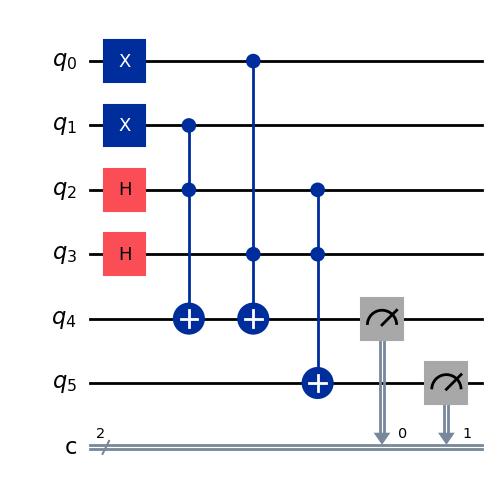

In [766]:
from qiskit import QuantumCircuit
# from qiskit.primitives import StatevectorSampler
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import CCXGate, XGate, HGate
from qiskit.primitives import StatevectorSampler


sampler = StatevectorSampler()
#qiskit initializes qbits to |0>
#x gates flip the qbit, so its good for making them |1> states
#qubits 0 and 1 are the so called aneary(?) qbits, as in, they don't change
qr = QuantumRegister(6,"q")
cr = ClassicalRegister(2,"c")

qc = QuantumCircuit(qr, cr, name='adder circuit')
#q2 and q3 should my opperands

#add randomness
qc.append(HGate(), [2])
qc.append(HGate(), [3])


qc.append(XGate(), [0])
qc.append(XGate(), [1])
# qc.append(CCXGate(), [0,1,2])
# qc.append(CCXGate(), [0,1,3])

#XOR (sum):

qc.append(CCXGate(), [1,2,4])
qc.append(CCXGate(), [0,3,4])


#AND (carry):
qc.append(CCXGate(), [2,3,5])

#make sure its all reversable

# qc.append(CCXGate(), [1,2,4])

# qc.append(CCXGate(), [0,1,3])
# qc.append(CCXGate(), [0,1,2])



#this represent an AND gate, where q2 is flipped if q0 and q1 are 1 (which they are)
#q5 should hold my result
#xor opperation for the carry: q4 contains 
# qc.append(CCXGate(), [1,2,3])
qc.measure(4,0)
#carry
qc.measure(5,1)
#          ^ indicates what qubit is being meassured
#            ^ indicates in what classical register is the meassurement being depoosited in

qc.draw("mpl")

To specify what values we are going to add, we are going to have to flip them. For example: For 0 + 1, we would have to flip q3 with an xgate. Perhaps this can be achived with an if statement and function arguments. 

In [767]:

# qc.measure_all()
result = sampler.run([qc], shots=1024).result()
print(result[0].data)
# print(dir(result[0].data.c6.get_counts()))

DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=2>))


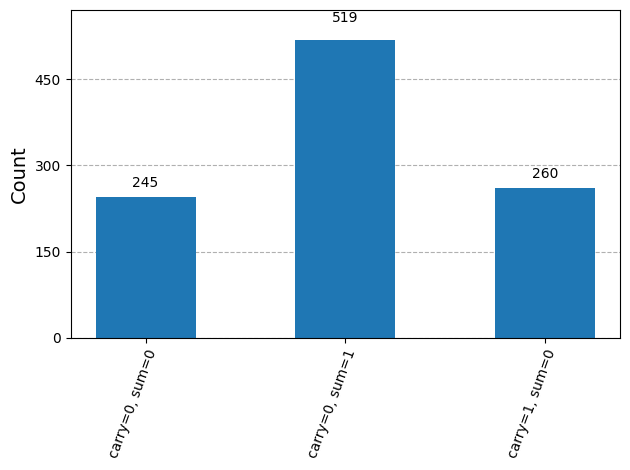

In [768]:
counts = result[0].data.c.get_counts()
pretty_counts = {
    "carry=0, sum=0": counts.get("00", 0),
    "carry=0, sum=1": counts.get("01", 0),
    "carry=1, sum=0": counts.get("10", 0),
    # "carry=1, sum=1": counts.get("11", 0),
}

plot_histogram(pretty_counts)

Full adder

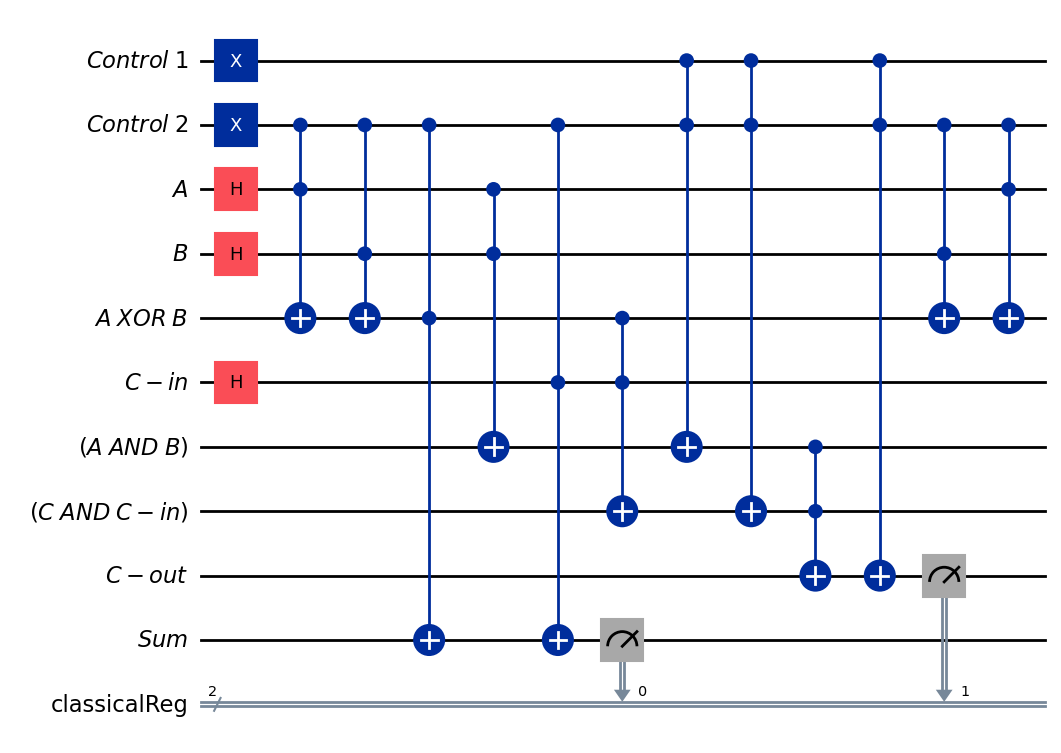

In [769]:
from qiskit import QuantumCircuit
# from qiskit.primitives import StatevectorSampler
from qiskit.circuit import QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import CCXGate, XGate, HGate
from qiskit.primitives import StatevectorSampler

    

sampler = StatevectorSampler()
#qiskit initializes qbits to |0>
#x gates flip the qbit, so its good for making them |1> states
#qubits 0 and 1 are the so called aneary(?) qbits, as in, they don't change
qr0 = QuantumRegister(1,"Control 1")
qr1 = QuantumRegister(1,"Control 2")
qr2 = QuantumRegister(1,"A")
qr3 = QuantumRegister(1,"B")
qr4 = QuantumRegister(1,"A XOR B")
qr5 = QuantumRegister(1,"C-in")
qr6 = QuantumRegister(1,"(A AND B)")
qr7 = QuantumRegister(1,"(C AND C-in)")
qr8 = QuantumRegister(1,"C-out")
qr9 = QuantumRegister(1,"Sum")


cr = ClassicalRegister(2,"classicalReg")

qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, cr, name='Full-adder circuit')

#add randomness
qc.append(HGate(), [2])
qc.append(HGate(), [3])
qc.append(HGate(), [5])

#order:
# 0 = Control 1
# 1 = Control 2
# 2 = A
# 3 = B
# 4 = C
# 5 = C-in
# 6 = (A and B)
# 7 = (C and C-in)
# 8 = (C-out) 
# 9 = SUM


#set the control bit to |1>
qc.append(XGate(), [0])
qc.append(XGate(), [1])

#set up the SUM
#First XOR (sum):
#XOR A and B to fill C
qc.append(CCXGate(), [1,2,4])
qc.append(CCXGate(), [1,3,4])

#Perform XOR between C and C-in to get the sum
qc.append(CCXGate(), [1,4,9])
qc.append(CCXGate(), [1,5,9])

#Sum is done

#C-OUT

#First, AND between A and B
qc.append(CCXGate(),[2,3,6])

#Then, AND between C and C-IN
qc.append(CCXGate(),[4,5,7])


#Finally, OR both of the opperated qbits
#Invert both
# NOT(A and B)
qc.append(CCXGate(),[0,1,6])
# NOT(C and C-in)
qc.append(CCXGate(),[0,1,7])

#Apply DEmorgan (AND (NOT(A and B) and (NOT(C and C-in)) and get the C-Out

qc.append(CCXGate(),[6,7,8])

#Apply the final inversion of de morgan:

qc.append(CCXGate(),[0,1,8])


#Reverse the opperation due to entanglement:
qc.append(CCXGate(), [1,3,4])
qc.append(CCXGate(), [1,2,4])







#this represent an AND gate, where q2 is flipped if q0 and q1 are 1 (which they are)
#q5 should hold my result

#xor opperation for the carry: q4 contains 
#get the SUM first
qc.measure(9,0)
# Then the carry-out
qc.measure(8,1)


qc.draw("mpl")

In [770]:

# qc.measure_all()
result = sampler.run([qc], shots=(30 * 1024)).result()
print(result[0].data)
# print(dir(result[0].data.c6.get_counts()))

DataBin(classicalReg=BitArray(<shape=(), num_shots=30720, num_bits=2>))


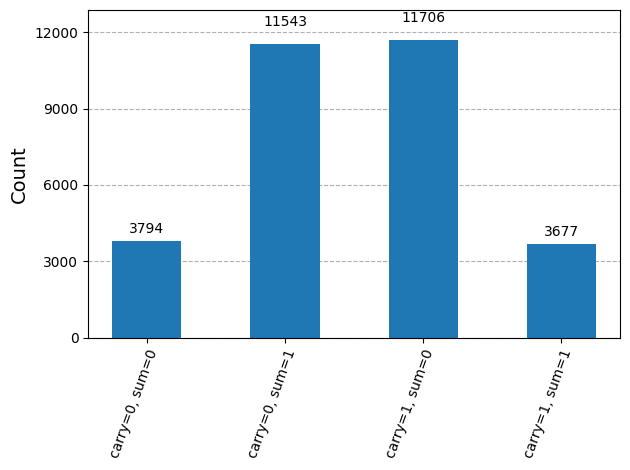

In [771]:
counts = result[0].data.classicalReg.get_counts()
pretty_counts = {
    "carry=0, sum=0": counts.get("00", 0),
    "carry=0, sum=1": counts.get("01", 0),
    "carry=1, sum=0": counts.get("10", 0),
    "carry=1, sum=1": counts.get("11", 0),

    # "carry=1, sum=1": counts.get("11", 0),
}

plot_histogram(pretty_counts)

dist for a full adder's truth table:

00: 1

10: 3

01: 3

11: 1